# TD1 — Embeddings: from words to meaning

**~1h · the first brick of the PIM assistant you build across TD1–TD5.**

The big question: *how can a machine represent the **meaning** of a product, so that two similar products are "close" even when they don't share any words?*

By the end of this lab you can:
1. explain **why** we need embeddings (and why plain word-matching fails);
2. measure semantic proximity with **cosine similarity** and build a small **semantic search**;
3. **read** an embedding space in 2D;
4. treat *"which model?"* as an **engineering trade-off**.

**How to work:** run the notebook top to bottom; complete the `# TODO` cells; and **ask Claude Code first** whenever you're stuck. 🚀

## 1. Setup

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

%matplotlib inline

# Shared PIM catalog — the same dataset used in TD2, TD3, TD4.
df = pd.read_csv("../data/products.csv")

# The text we embed for each product: its name plus the long description.
df["text"] = df["name"] + " — " + df["long_description"]

print(f"Loaded {len(df)} products across {df['category'].nunique()} categories.")
df[["sku", "name", "brand", "category", "price"]].head(3)

Loaded 198 products across 22 categories.


,sku,name,brand,category,price
0,SKU-0001,Sony WH-1000XM5,Sony,Headphones,379.0
1,SKU-0002,Bose QuietComfort Ultra,Bose,Headphones,449.0
2,SKU-0003,Sennheiser Momentum 4 Wireless,Sennheiser,Headphones,299.0


## 2. Why not just match words?

Before embeddings, the simplest way to compare two texts is to look at the **words they share**. This is the spirit of **one-hot** / **bag-of-words** encoding from the lecture: each word becomes its own independent dimension, and a text is just the set (or count) of words it contains.

The problem: this representation sees only **surface tokens**, never **meaning**. Let's make that concrete with a tiny *lexical* similarity (Jaccard overlap on word sets).

In [2]:
def lexical_similarity(a, b):
    """Jaccard overlap on lowercased word sets: do two strings share words?"""
    wa, wb = set(a.lower().split()), set(b.lower().split())
    return len(wa & wb) / len(wa | wb)

same_meaning = ("wireless noise-cancelling over-ear headphones",
                "premium bluetooth headset with active noise cancellation")
shared_word = ("apple watch", "apple pie recipe")

print("Same meaning, few shared words:")
print(f"  lexical similarity = {lexical_similarity(*same_meaning):.2f}")
print("Different meaning, a shared word:")
print(f"  lexical similarity = {lexical_similarity(*shared_word):.2f}")

Same meaning, few shared words:
  lexical similarity = 0.00
Different meaning, a shared word:
  lexical similarity = 0.25


**Question.** Why is lexical (word-overlap) similarity a poor measure of product similarity? Relate it to the limits of one-hot / bag-of-words encoding from the lecture.

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

La similarité lexicale ne regarde que les mots exactement partagés entre deux textes, jamais leur sens. En one-hot/bag-of-words, "headphones" et "headset" sont considérés comme aussi différents que "headphones" et "banana", alors qu'ils veulent dire à peu près la même chose. Du coup deux produits qui parlent de la même chose avec un vocabulaire différent obtiennent un score de 0 (comme les deux casques dans l'exemple), tandis que deux produits qui n'ont rien à voir mais partagent un mot fréquent ("apple") ressortent comme proches. Le problème de fond est que cette représentation capture la surface (les tokens) et pas le sens, elle ignore les synonymes, les paraphrases et le contexte. 

## 3. From text to vector (embeddings)

An **embedding model** maps any piece of text to a fixed-length vector of numbers (e.g. 384 values) that is meant to capture its **meaning**: texts with similar meaning land at nearby points in that high-dimensional space. We'll use [`sentence-transformers`](https://www.sbert.net/), which downloads a small pretrained model and runs it **locally** — no API, no cost.

In [3]:
# Small, fast embedding model (downloads on first run; cached afterwards).
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("Wireless noise-cancelling headphones")
print(f"Embedding dimension: {vec.shape[0]}")
print(f"First 5 values: {vec[:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding dimension: 384
First 5 values: [-0.05025909  0.06580363  0.00443389  0.03372141 -0.04303833]


In [4]:
# TODO: encode BOTH strings of `same_meaning` in one call (pass them as a list).
#       Store the (2, 384) array in `pair_emb`.
pair_emb = model.encode(list(same_meaning))

print(pair_emb.shape if pair_emb is not None else "Not implemented yet.")

(2, 384)


## 4. Cosine similarity & nearest neighbours

Now we have vectors — how do we measure how *close in meaning* two of them are? The standard tool is **cosine similarity**: it's the cosine of the angle between the two vectors, so it cares about their **direction**, not their length.

$$\cos(\theta) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

Intuition: **1** = same direction (same meaning), **0** = unrelated (perpendicular), **−1** = opposite. This is the centerpiece of the whole lab.

In [5]:
def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||). ~1 = same direction (meaning), ~0 = unrelated."""
    # TODO: implement with numpy (np.dot, np.linalg.norm). Return a float.
    ab = np.dot(a,b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return ab / (norm_a * norm_b)

# Self-check once implemented:
print(cosine_similarity(np.array([1., 0]), np.array([1., 0])))  # -> 1.0
print(cosine_similarity(np.array([1., 0]), np.array([0., 1])))  # -> 0.0

1.0
0.0


In [6]:
emb_same = model.encode(list(same_meaning))
emb_shared = model.encode(list(shared_word))

print("Embeddings — same meaning, few shared words :",
      round(cosine_similarity(emb_same[0], emb_same[1]), 2))
print("Embeddings — shared word, different meaning :",
      round(cosine_similarity(emb_shared[0], emb_shared[1]), 2))

Embeddings — same meaning, few shared words : 0.72
Embeddings — shared word, different meaning : 0.26


Notice how the **verdict flips** compared to the lexical score: the two paraphrased headphones are now *close*, and "apple watch" / "apple pie" are *far apart*. Meaning has become geometry.

Now let's scale this up to the whole catalog.

In [7]:
catalog_emb = model.encode(df["text"].tolist())
print("Catalog embeddings:", catalog_emb.shape)  # (198, 384)

Catalog embeddings: (198, 384)


In [11]:
def top_k_similar(query, catalog_emb, model, k=5):
    """Return the k catalog products most similar to `query`, as a DataFrame with a 'similarity' column.
    Steps: (1) embed the query; (2) cosine-score it against every row of catalog_emb;
           (3) take the k highest-scoring indices; (4) return df.iloc[indices] + a 'similarity' column."""
    # TODO: implement
    emb_query = model.encode(query)
    similarities = [cosine_similarity(emb_query, emb) for emb in catalog_emb]
    top_k_indices = np.argsort(similarities)[-k:][::-1]
    result_df = df.iloc[top_k_indices].copy()
    result_df["similarity"] = [similarities[i] for i in top_k_indices]
    return result_df

top_k_similar("something to listen to music on the train", catalog_emb, model)[["name", "category", "similarity"]]

,name,category,similarity
19,Bose SoundLink Flex,Bluetooth Speakers,0.336392
4,JBL Tour One M2,Headphones,0.336100
1,Bose QuietComfort Ultra,Headphones,0.331195
7,Marshall Major V,Headphones,0.319458
11,Bose QuietComfort Ultra Earbuds,Wireless Earbuds,0.291679


In [12]:
queries = [
    "a gift for someone who loves cooking",
    "portable speaker for the beach",
    "I want to read a science-fiction story",
]
for q in queries:
    print(f"\nQuery: {q!r}")
    print(top_k_similar(q, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))


Query: 'a gift for someone who loves cooking'
                                       name      category  similarity
Tefal Jamie Oliver Quick & Easy 5-Piece Set Cookware Sets    0.336581
          Ninja Foodi ZeroStick 5-Piece Set Cookware Sets    0.320400
       Tefal Ingenio Expertise 10-Piece Set Cookware Sets    0.309757

Query: 'portable speaker for the beach'
                   name           category  similarity
    Bose SoundLink Flex Bluetooth Speakers    0.536110
Tribit StormBox Micro 2 Bluetooth Speakers    0.432882
        JBL Tour One M2         Headphones    0.385503

Query: 'I want to read a science-fiction story'
                name category  similarity
   Project Hail Mary    Books    0.352839
The Midnight Library    Books    0.342060
     Le Petit Prince    Books    0.282375


You just built a tiny **vector search** — a query goes in, the most semantically similar products come out. In **TD3** you'll replace this numpy loop with **ChromaDB**, a real vector database; that's the *retrieval* half of RAG.

**Question.** Pick one vague query of your own (run it with `top_k_similar`). Are the neighbours sensible? Where does it struggle, and why?

**Your answer** — write it yourself (AI may help you think, but the answer must be your own). Paste your query, then a one-paragraph observation.

Notre requête : "a gift for a gamer". 

Les voisins sont plutôt pertinents : le modèle remonte des manettes, un PC portable gaming et la Xbox Series X. On est bien dans l'univers du jeu vidéo, alors qu'aucun de ces produits ne contient les mots "gift" ni "gamer". Le problème c'est que les scores de similarité restent faibles (0.32-0.37) et assez proches les uns des autres puisque la requête reste vague, on n'a pas préciser le budget ni le type de gamer. Le modèle attrape le thème général "gaming" mais ne peut pas trancher entre une manette et un PC à 2000€, et il rate peut-être des cadeaux pertinents qui ne sont pas étiquetés jeu vidéo (un casque, une carte cadeau…).

In [13]:
query = "a gift for a gamer"

top_k_similar(query, catalog_emb, model)[["name", "category", "similarity"]]

,name,category,similarity
128,Sony DualSense Edge,Controllers,0.370875
129,Microsoft Xbox Elite Series 2,Controllers,0.358151
30,ASUS ROG Zephyrus G14,Laptops,0.334577
133,SCUF Reflex Pro,Controllers,0.327784
110,Microsoft Xbox Series X,Consoles,0.324308


## 5. Seeing the whole space (2D)

Our vectors live in 384 dimensions — we can't see that directly. **PCA** (Principal Component Analysis) projects them down to the 2 directions of greatest variance, so we can *plot* the catalog and look at its structure. Some information is lost in the projection, but the **big clusters survive** — and that's exactly what we want to inspect.

In [14]:
from sklearn.decomposition import PCA

# TODO: fit PCA(n_components=2) on `catalog_emb` and transform it to 2D.
#       Store the (198, 2) result in `coords_2d`.
coords_2d = PCA(n_components=2).fit_transform(catalog_emb)

print(coords_2d.shape if coords_2d is not None else "Not implemented yet.")

(198, 2)


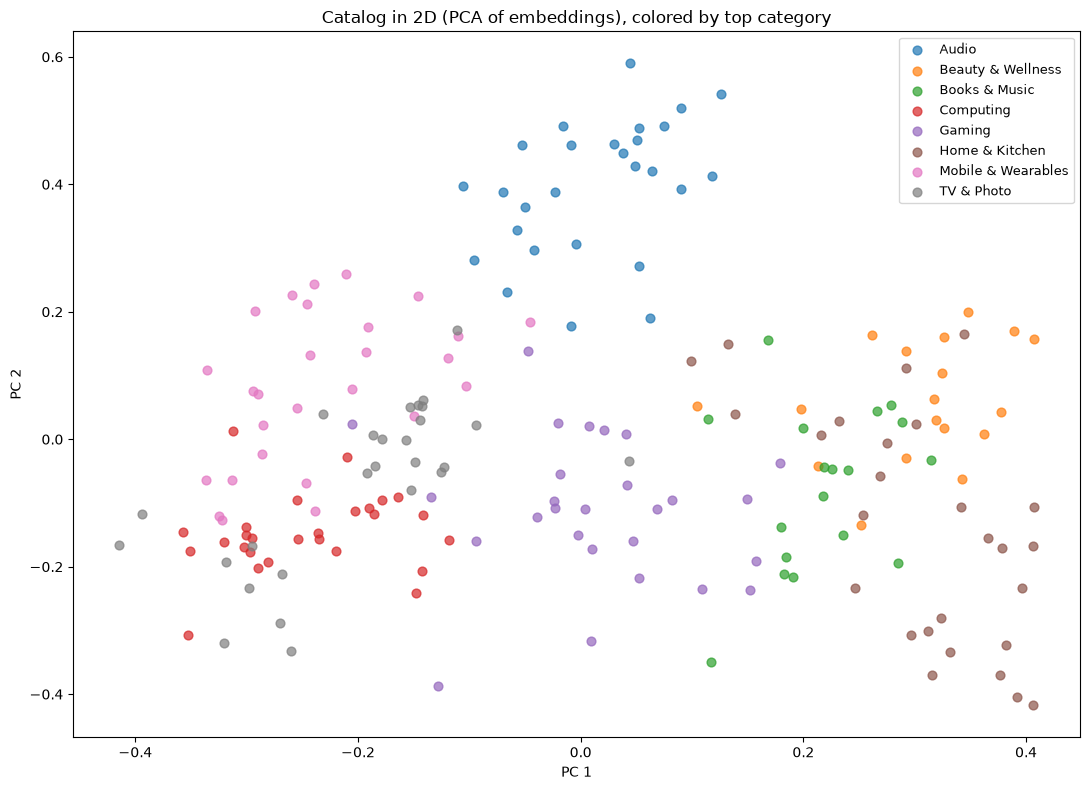

In [15]:
with open("../data/taxonomy.json") as f:
    taxo = json.load(f)
leaf_to_top = {sub["name"]: top["name"] for top in taxo["categories"] for sub in top["subcategories"]}
df["top_category"] = df["category"].map(leaf_to_top)

plt.figure(figsize=(11, 8))
for top in sorted(df["top_category"].unique()):
    mask = (df["top_category"] == top).values
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], label=top, alpha=0.7, s=40)
plt.legend(loc="best", fontsize=9)
plt.title("Catalog in 2D (PCA of embeddings), colored by top category")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

**Question.** Which categories form tight clusters? Which ones overlap? (Look in particular at *Headphones* vs *Wireless Earbuds*, and *Smartwatches* vs *Fitness Trackers*.) What does that predict about how hard categorization will be in TD2?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Sur la projection PCA, les catégories dont le vocabulaire et l'usage sont très spécifiques forment des clusters bien nets et séparés (par exemple les livres, les jeux vidéo, les ustensiles de cuisine). En revanche, les catégories sémantiquement voisines se recouvrent nettement : Headphones et Wireless Earbuds se mélangent parce que ce sont tous les deux des dispositifs audio portés sur les oreilles, décrits avec le même vocabulaire (bluetooth, noise-cancelling, autonomie), pareil pour Smartwatches et Fitness Trackers, qui partagent capteurs, suivi d'activité et poignet. 

Cela prédit que la catégorisation en TD2 sera facile sur les catégories isolées mais difficile précisément sur ces paires qui se chevauchent : un classifieur basé sur ces vecteurs confondra souvent écouteurs/casques et montres/trackers.

## 6. Does it work across languages?

Real catalogs and real queries are often **multilingual**. The `all-MiniLM-L6-v2` model we've used so far was trained mostly on English, so a **French** query may land in the wrong neighbourhood. This is the practical motivation for **multilingual models** — and a concrete instance of the lecture's **low-resource languages** point. Let's probe it.

In [16]:
fr_query = "écouteurs sans fil pour le sport"

# TODO:
#  1. Load the multilingual model "paraphrase-multilingual-MiniLM-L12-v2" as `model_multi`.
#  2. Re-embed the catalog with it -> `catalog_emb_multi`.
#  3. Top-3 for `fr_query` with the multilingual model (model_multi + catalog_emb_multi).
#  4. Top-3 for the SAME `fr_query` with the English-only model (model + catalog_emb).
#  5. Print both result lists and compare.
model_multi = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
catalog_emb_multi = model_multi.encode(df["text"].tolist())
top_3 = top_k_similar(fr_query, catalog_emb_multi, model_multi, k=3)[["name", "category", "similarity"]]
top_3_eng = top_k_similar(fr_query, catalog_emb, model, k=3)[["name", "category", "similarity"]]

print("Top 3 with multilingual model:")
print(top_3)
print("\nTop 3 with English-only model:")
print(top_3_eng)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\tomil\Documents\Generative-AI-M2-Apprentissage-2026-students\genai_env\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomil\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Top 3 with multilingual model:
                    name            category  similarity
21  Ultimate Ears BOOM 4  Bluetooth Speakers    0.508923
0        Sony WH-1000XM5          Headphones    0.499929
5       Beats Studio Pro          Headphones    0.497242

Top 3 with English-only model:
                name     category  similarity
120  EA Sports FC 25  Video Games    0.314305
169  Le Petit Prince        Books    0.221530
121  Forza Horizon 5  Video Games    0.214924


**Question.** Why does the multilingual model handle the French query better? Link this to *"low-resource languages"* and to when you'd reach for **fine-tuning** (from the lecture).

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Le modèle multilingue gère mieux les requêtes en français vu qu'il a été entrainé sur plusieurs langues (dont le français) alors que le modèle "all-MiniLM-L6-v2" a été entrainé sur des données en anglais donc son espace vectoriel ne représente pas correctement le vocabulaire français.

On utiliserait le fine-tuning pour un domaine spécifique et donc le modèle n'a pas pu s'entrainer dessus car c'est un domaine niche vu que le modèle est assez général. Ou sinon pour une langue qui n'est pas/très peu représentée dans le modèle multilingues et donc il faudra réentrainer avec la langue cible.

## 7. Choosing an embedding model

There is no single "best" embedding model — it's an **engineering trade-off** along several axes: **dimensionality** (memory + storage in the vector DB), **encoding speed** (latency / cost at scale), **semantic quality**, and **language coverage**. The cell below *measures* three candidates so you can compare them on our own catalog. (`category_consistency` is a quick quality proxy: for a sample of products, is the nearest *other* product in the same leaf category? Higher = the space separates categories better.)

In [17]:
def category_consistency(embs, sample=60, seed=0):
    """Quality proxy: for a sample of products, is the nearest *other* product in the same leaf
    category? Higher = the space separates categories better."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample, len(df)), replace=False)
    norm = embs / np.linalg.norm(embs, axis=1, keepdims=True)
    hits = 0
    for i in idx:
        sims = norm @ norm[i]
        sims[i] = -1.0
        nn = int(np.argmax(sims))
        hits += int(df.iloc[nn]["category"] == df.iloc[i]["category"])
    return hits / len(idx)

candidates = ["all-MiniLM-L6-v2", "all-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2"]
rows = []
for name in candidates:
    m = SentenceTransformer(name)
    t0 = time.perf_counter()
    embs = m.encode(df["text"].tolist())
    dt = time.perf_counter() - t0
    rows.append({"model": name, "dim": embs.shape[1],
                 "encode_time_s": round(dt, 2),
                 "category_consistency": round(category_consistency(embs), 2)})
measure_df = pd.DataFrame(rows)
measure_df

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\tomil\Documents\Generative-AI-M2-Apprentissage-2026-students\genai_env\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomil\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,model,dim,encode_time_s,category_consistency
0,all-MiniLM-L6-v2,384,1.02,0.68
1,all-mpnet-base-v2,768,7.02,0.78
2,paraphrase-multilingual-MiniLM-L12-v2,384,2.20,0.68


**Question.** Read the table. Which model would you pick for this PIM, and why? In what situation would the **multilingual** model be the right default even if another scores higher here?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Cela dépend de ce qu'on veut pour notre PIM. On pourrait choisir le modèle "all-MiniLM-L6-v2" si on veut le meilleur compromis qualité/vitesse/taille vu qu'il est 7 fois plus rapide à encoder que le modèle "all-mpnet-base-v2" et il produit aussi des vecteurs deux fois plus petit et qu'il a quand même un bon score de consistance (0.68 contre 0.78). Cependant, si on veut un modèle qui soit le plus précis possible peu importe le temps que cela prend, je choisirais le modèle "all-mpnet-base-v2". Personnellement, je préfère la rapidité et le fait que la taille des vecteurs est plus petite ce qui est important pour notre base vectorielle donc je choisirais "all-MiniLM-L6-v2". 

Le modèle multilingual peut être choisi si la langue n'est pas forcément l'anglais, donc pour des requêtes en français par exemple. Utile si on a des utilisateurs internationales pour le catalogue. Il reste un bon modèle avec la même consistance et taille que le modèle "all-MiniLM-L6-v2" mais juste un peu plus lent pour l'encodage.

## 8. Wrap-up

What you take away from TD1:

- **Meaning becomes geometry.** An embedding turns text into a vector so that *similar meaning → nearby vector* — which is why word-overlap fails and cosine similarity works.
- The **`top_k_similar`** function you wrote *is* the **retrieval engine** behind RAG (TD3) and a **classification signal** (nearest-neighbour → TD2).
- The **2D view** shows where categories overlap — and that's exactly where TD2 categorization gets hard.
- **Model choice is a trade-off** (dimensionality, speed, quality, language coverage), not a search for one "best" model.

**Next:** **TD2** uses these vectors as features for a classifier and contrasts it with a zero-shot LLM; **TD3** turns your mini search into a real RAG with **ChromaDB**. ✅